<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-classification-experiments/Classification_model_02(by_our_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# STEP 1: MOUNT DRIVE AND EXTRACT DATASET
# ==========================================
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

# Make sure this is the correct name of your zip file in Drive
zip_path = '/content/drive/MyDrive/fabric_dataset.zip'
extract_path = '/content/fabric_dataset'

# Extract the zip file if it hasn't been extracted yet
if not os.path.exists(extract_path):
    try:
        print("⏳ Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Dataset extracted successfully!")
    except FileNotFoundError:
        print(f"❌ Error: Could not find the zip file at {zip_path}. Please check the filename in your Google Drive.")
else:
    print("✅ Dataset is already extracted and ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset is already extracted and ready.


In [ ]:
# ==========================================
# STEP 2: COMPLETE HYBRID MODEL TRAINING CODE
# ==========================================

# 1. Import Required Libraries
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
import tensorflow as tf
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ---------------------------------------------------------
# 2. Setup Data Paths and Labels
# ---------------------------------------------------------
# DIRECT PATH AS REQUESTED
original_dataset_dir = '/content/fabric_dataset/fabric_dataset'

if not os.path.exists(original_dataset_dir):
    print(f"❌ Error: The path {original_dataset_dir} does not exist. Check Cell 1 extraction.")
else:
    # Automatically detect fabric classes from folder names
    classes = sorted([d for d in os.listdir(original_dataset_dir) if os.path.isdir(os.path.join(original_dataset_dir, d))])
    class_indices = {cls: i for i, cls in enumerate(classes)}
    NUM_CLASSES = len(classes)

    print(f"Detected {NUM_CLASSES} classes: {classes}")

    all_paths, all_labels = [], []
    for cls in classes:
        cls_dir = os.path.join(original_dataset_dir, cls)
        for img_name in os.listdir(cls_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_paths.append(os.path.join(cls_dir, img_name))
                all_labels.append(class_indices[cls])

    # Split data into 80% Training and 20% Validation
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )

# ---------------------------------------------------------
# 3. LBP Feature Extraction Function
# ---------------------------------------------------------
RADIUS = 3
N_POINTS = 8 * RADIUS

def extract_lbp_features(image_array):
    """Extracts Local Binary Pattern (LBP) texture features from an image array."""
    # Convert float64 image array (0.0-1.0) back to uint8 (0-255) for OpenCV processing
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))

    # Calculate LBP and its histogram
    lbp = local_binary_pattern(gray, N_POINTS, RADIUS, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, N_POINTS + 3), range=(0, N_POINTS + 2))

    # Normalize the histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# ---------------------------------------------------------
# 4. Custom Hybrid Data Generator (On-the-fly Augmentation)
# ---------------------------------------------------------
class AugmentedHybridDataGenerator(Sequence):
    def __init__(self, image_paths, labels, batch_size=32, target_size=(224, 224), num_classes=9, augment=True, **kwargs):
        super().__init__(**kwargs)
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.num_classes = num_classes
        self.augment = augment

        # Define image augmentation rules
        self.datagen = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_labels = self.labels[idx * self.batch_size : (idx + 1) * self.batch_size]

        batch_images, batch_lbp, batch_y = [], [], []

        for i in range(len(batch_paths)):
            img = cv2.imread(batch_paths[i])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.target_size)

                # Apply dynamic augmentation only if enabled
                if self.augment:
                    img = self.datagen.random_transform(img)

                # Normalize pixel values
                img_normalized = img / 255.0
                batch_images.append(img_normalized)

                # Extract texture features
                lbp_features = extract_lbp_features(img_normalized)
                batch_lbp.append(lbp_features)

                batch_y.append(batch_labels[i])

        return {'rgb_image_input': np.array(batch_images), 'lbp_feature_input': np.array(batch_lbp)}, \
               to_categorical(np.array(batch_y), num_classes=self.num_classes)

if os.path.exists(original_dataset_dir):
    # Initialize data generators
    train_gen = AugmentedHybridDataGenerator(train_paths, train_labels, num_classes=NUM_CLASSES, augment=True)
    val_gen = AugmentedHybridDataGenerator(val_paths, val_labels, num_classes=NUM_CLASSES, augment=False)

    # ---------------------------------------------------------
    # 5. Build Attention-Enhanced Hybrid Architecture
    # ---------------------------------------------------------
    # Branch 1: Deep Features (MobileNetV2)
    image_input = Input(shape=(224, 224, 3), name='rgb_image_input')
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)
    base_model.trainable = False
    cnn_features = GlobalAveragePooling2D()(base_model.output)

    # Branch 2: Texture Features (LBP)
    lbp_input = Input(shape=(26,), name='lbp_feature_input')
    texture_features = Dense(64, activation='relu')(lbp_input)
    texture_features = Dropout(0.3)(texture_features)
    texture_features = Dense(32, activation='relu')(texture_features)

    # Fusion
    combined_features = Concatenate()([cnn_features, texture_features])

    # CBAM-Style 1D Channel Attention Mechanism
    attention_dim = combined_features.shape[-1] // 8
    attention = Dense(attention_dim, activation='relu', use_bias=False)(combined_features)
    attention = Dense(combined_features.shape[-1], activation='sigmoid', use_bias=False)(attention)
    attended_features = Multiply(name='attention_multiplication')([combined_features, attention])

    # Classification Head
    x = Dense(128, activation='relu')(attended_features)
    x = Dropout(0.4)(x)
    final_output = Dense(NUM_CLASSES, activation='softmax', name='classification_output')(x)

    # Define and Compile the Model
    cbam_hybrid_model = Model(inputs=[image_input, lbp_input], outputs=final_output)
    cbam_hybrid_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                              loss='categorical_crossentropy',
                              metrics=['accuracy'])

    print("\n✅ Hybrid Model successfully built!")

    # ---------------------------------------------------------
    # 6. Callbacks and Model Training
    # ---------------------------------------------------------
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    checkpoint = ModelCheckpoint('/content/best_cbam_hybrid_model.keras',
                                 monitor='val_accuracy',
                                 save_best_only=True)

    print("\n🚀 Starting model training... ⏳")

    # Execute training process
    history = cbam_hybrid_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        callbacks=[early_stop, checkpoint]
    )

    print("\n✅ Training completed! The best model is saved as 'best_cbam_hybrid_model.keras'")

Detected 9 classes: ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']


/tmp/ipykernel_988/1688659214.py:136: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

✅ Hybrid Model successfully built!

🚀 Starting model training... ⏳
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1611s 18s/step - accuracy: 0.4604 - loss: 1.5033 - val_accuracy: 0.4341 - val_loss: 1.4967
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1588s 18s/step - accuracy: 0.5781 - loss: 1.1861 - val_accuracy: 0.4577 - val_loss: 1.4489
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1590s 18s/step - accuracy: 0.6125 - loss: 1.0940 - val_accuracy: 0.4369 - val_loss: 1.4697
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1576s 18s/step - accuracy: 0.6295 - loss: 1.0459 - val_accuracy: 0.4854 - val_loss: 1.3742
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1584s 18s/step - accuracy: 0.6417 - loss: 1.0083 - val_accuracy: 0.5173 - val_loss: 1.2997
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1578s 18s/step - accuracy: 0.6698 - loss: 0.9368 - val_accuracy: 0.4993 - val_loss: 1.4024
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1576s 18s/step - accuracy: 0.6910 - loss: 0.8955 - val_accuracy: 0.5049

⏳ Loading the best model...
✅ Model loaded successfully!

📸 Please upload a fabric image from your phone/computer to test...


Saving viscose.jpeg to viscose.jpeg

⚙️ Processing 'viscose.jpeg' (Full Image)...
🤖 Model is analyzing the full texture...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


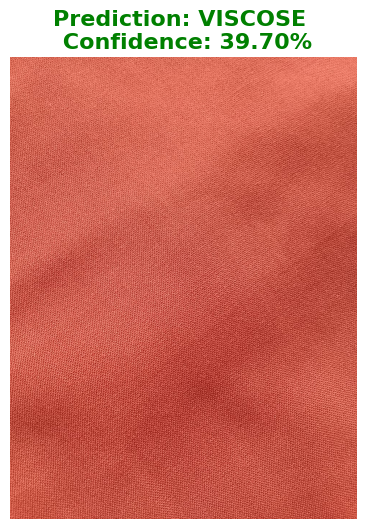

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model
from skimage.feature import local_binary_pattern

# 1. Load the best saved model
print("⏳ Loading the best model...")
model_path = '/content/best_cbam_hybrid_model.keras'
test_model = load_model(model_path)
print("✅ Model loaded successfully!\n")

# LBP Function
def extract_lbp_features(image_array):
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))
    lbp = local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Class labels
fabric_classes = ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

print("📸 Please upload a fabric image from your phone/computer to test...")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⚙️ Processing '{filename}' (Full Image)...")

    # Read Image
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 🖼️ NO ZOOM: Process the full original image directly
    # ---------------------------------------------------------
    # Simply resize the original image to 224x224 for the model
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize for Model
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Extract LBP from the full image
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0)

    # ---------------------------------------------------------
    # 🤖 PREDICTION
    # ---------------------------------------------------------
    print("🤖 Model is analyzing the full texture...")
    predictions = test_model.predict({'rgb_image_input': img_input, 'lbp_feature_input': lbp_input})

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = fabric_classes[predicted_index]

    # ---------------------------------------------------------
    # 📊 DISPLAY RESULTS
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    print("✅ Testing completed!")

⏳ Loading the best model...
✅ Model loaded successfully!

📸 Please upload a fabric image from your phone/computer to test...


Saving d.jfif to d.jfif

⚙️ Processing 'd.jfif' (Full Image)...
🤖 Model is analyzing the full texture...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


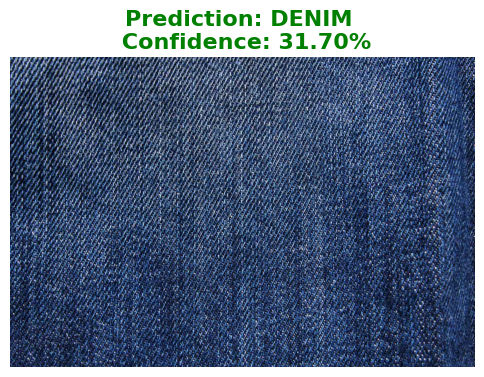

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model
from skimage.feature import local_binary_pattern

# 1. Load the best saved model
print("⏳ Loading the best model...")
model_path = '/content/best_cbam_hybrid_model.keras'
test_model = load_model(model_path)
print("✅ Model loaded successfully!\n")

# LBP Function
def extract_lbp_features(image_array):
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))
    lbp = local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Class labels
fabric_classes = ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

print("📸 Please upload a fabric image from your phone/computer to test...")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⚙️ Processing '{filename}' (Full Image)...")

    # Read Image
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 🖼️ NO ZOOM: Process the full original image directly
    # ---------------------------------------------------------
    # Simply resize the original image to 224x224 for the model
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize for Model
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Extract LBP from the full image
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0)

    # ---------------------------------------------------------
    # 🤖 PREDICTION
    # ---------------------------------------------------------
    print("🤖 Model is analyzing the full texture...")
    predictions = test_model.predict({'rgb_image_input': img_input, 'lbp_feature_input': lbp_input})

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = fabric_classes[predicted_index]

    # ---------------------------------------------------------
    # 📊 DISPLAY RESULTS
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    print("✅ Testing completed!")

⏳ Loading the best model...
✅ Model loaded successfully!

📸 Please upload a fabric image from your phone/computer to test...


Saving cot.jpg to cot (2).jpg

⚙️ Processing 'cot (2).jpg' (Full Image)...
🤖 Model is analyzing the full texture...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


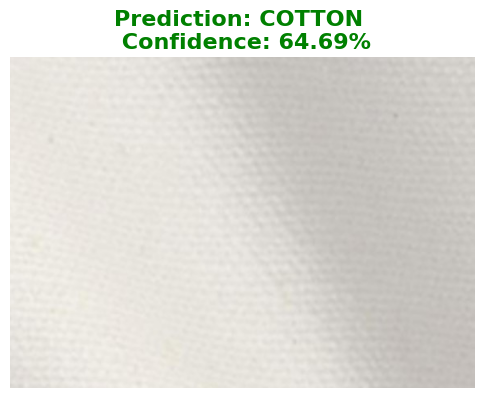

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model
from skimage.feature import local_binary_pattern

# 1. Load the best saved model
print("⏳ Loading the best model...")
model_path = '/content/best_cbam_hybrid_model.keras'
test_model = load_model(model_path)
print("✅ Model loaded successfully!\n")

# LBP Function
def extract_lbp_features(image_array):
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))
    lbp = local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Class labels
fabric_classes = ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

print("📸 Please upload a fabric image from your phone/computer to test...")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⚙️ Processing '{filename}' (Full Image)...")

    # Read Image
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 🖼️ NO ZOOM: Process the full original image directly
    # ---------------------------------------------------------
    # Simply resize the original image to 224x224 for the model
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize for Model
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Extract LBP from the full image
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0)

    # ---------------------------------------------------------
    # 🤖 PREDICTION
    # ---------------------------------------------------------
    print("🤖 Model is analyzing the full texture...")
    predictions = test_model.predict({'rgb_image_input': img_input, 'lbp_feature_input': lbp_input})

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = fabric_classes[predicted_index]

    # ---------------------------------------------------------
    # 📊 DISPLAY RESULTS
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    print("✅ Testing completed!")

⏳ Loading the best model...
✅ Model loaded successfully!

📸 Please upload a fabric image from your phone/computer to test...


Saving silk.png to silk.png

⚙️ Processing 'silk.png' (Full Image)...
🤖 Model is analyzing the full texture...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


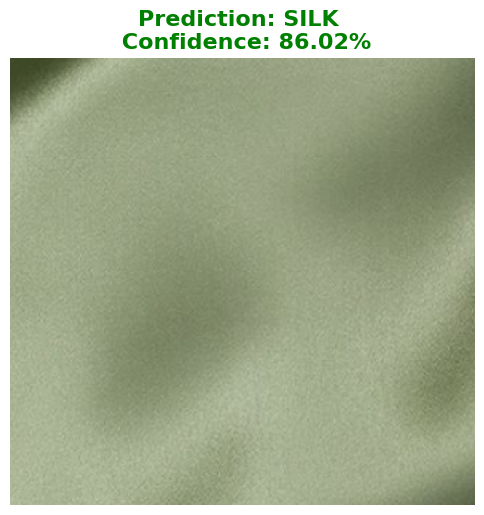

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model
from skimage.feature import local_binary_pattern

# 1. Load the best saved model
print("⏳ Loading the best model...")
model_path = '/content/best_cbam_hybrid_model.keras'
test_model = load_model(model_path)
print("✅ Model loaded successfully!\n")

# LBP Function
def extract_lbp_features(image_array):
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))
    lbp = local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Class labels
fabric_classes = ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

print("📸 Please upload a fabric image from your phone/computer to test...")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⚙️ Processing '{filename}' (Full Image)...")

    # Read Image
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 🖼️ NO ZOOM: Process the full original image directly
    # ---------------------------------------------------------
    # Simply resize the original image to 224x224 for the model
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize for Model
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Extract LBP from the full image
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0)

    # ---------------------------------------------------------
    # 🤖 PREDICTION
    # ---------------------------------------------------------
    print("🤖 Model is analyzing the full texture...")
    predictions = test_model.predict({'rgb_image_input': img_input, 'lbp_feature_input': lbp_input})

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = fabric_classes[predicted_index]

    # ---------------------------------------------------------
    # 📊 DISPLAY RESULTS
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    print("✅ Testing completed!")

⏳ Loading the best model...
✅ Model loaded successfully!

📸 Please upload a fabric image from your phone/computer to test...


Saving wool.jpg to wool.jpg

⚙️ Processing 'wool.jpg' (Full Image)...
🤖 Model is analyzing the full texture...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


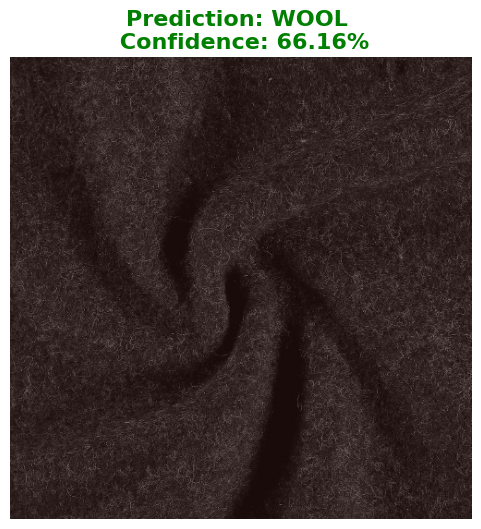

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model
from skimage.feature import local_binary_pattern

# 1. Load the best saved model
print("⏳ Loading the best model...")
model_path = '/content/best_cbam_hybrid_model.keras'
test_model = load_model(model_path)
print("✅ Model loaded successfully!\n")

# LBP Function
def extract_lbp_features(image_array):
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))
    lbp = local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Class labels
fabric_classes = ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

print("📸 Please upload a fabric image from your phone/computer to test...")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⚙️ Processing '{filename}' (Full Image)...")

    # Read Image
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 🖼️ NO ZOOM: Process the full original image directly
    # ---------------------------------------------------------
    # Simply resize the original image to 224x224 for the model
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize for Model
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Extract LBP from the full image
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0)

    # ---------------------------------------------------------
    # 🤖 PREDICTION
    # ---------------------------------------------------------
    print("🤖 Model is analyzing the full texture...")
    predictions = test_model.predict({'rgb_image_input': img_input, 'lbp_feature_input': lbp_input})

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = fabric_classes[predicted_index]

    # ---------------------------------------------------------
    # 📊 DISPLAY RESULTS
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    print("✅ Testing completed!")

⏳ Loading the best model...
✅ Model loaded successfully!

📸 Please upload a fabric image from your phone/computer to test...


Saving poly_zoomed.jpg to poly_zoomed.jpg

⚙️ Processing 'poly_zoomed.jpg' (Full Image)...
🤖 Model is analyzing the full texture...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


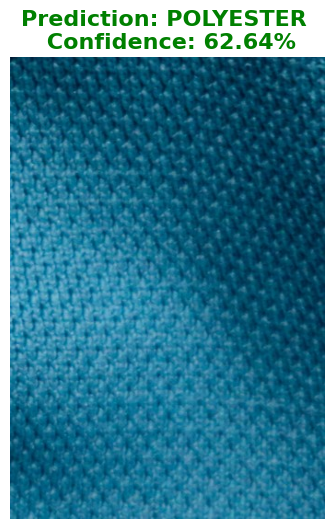

✅ Testing completed!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model
from skimage.feature import local_binary_pattern

# 1. Load the best saved model
print("⏳ Loading the best model...")
model_path = '/content/best_cbam_hybrid_model.keras'
test_model = load_model(model_path)
print("✅ Model loaded successfully!\n")

# LBP Function
def extract_lbp_features(image_array):
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))
    lbp = local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Class labels
fabric_classes = ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

print("📸 Please upload a fabric image from your phone/computer to test...")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⚙️ Processing '{filename}' (Full Image)...")

    # Read Image
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 🖼️ NO ZOOM: Process the full original image directly
    # ---------------------------------------------------------
    # Simply resize the original image to 224x224 for the model
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize for Model
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Extract LBP from the full image
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0)

    # ---------------------------------------------------------
    # 🤖 PREDICTION
    # ---------------------------------------------------------
    print("🤖 Model is analyzing the full texture...")
    predictions = test_model.predict({'rgb_image_input': img_input, 'lbp_feature_input': lbp_input})

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = fabric_classes[predicted_index]

    # ---------------------------------------------------------
    # 📊 DISPLAY RESULTS
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    print("✅ Testing completed!")

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model
from skimage.feature import local_binary_pattern

# 1. Load the best saved model
print("⏳ Loading the best model...")
model_path = '/content/best_cbam_hybrid_model.keras'
test_model = load_model(model_path)
print("✅ Model loaded successfully!\n")

# LBP Function
def extract_lbp_features(image_array):
    img_uint8 = (image_array * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (224, 224))
    lbp = local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

# Class labels
fabric_classes = ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

print("📸 Please upload a fabric image from your phone/computer to test...")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f"\n⚙️ Processing '{filename}' (Full Image)...")

    # Read Image
    image_path = '/content/' + filename
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Error: Could not read the image.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 🖼️ NO ZOOM: Process the full original image directly
    # ---------------------------------------------------------
    # Simply resize the original image to 224x224 for the model
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Normalize for Model
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Extract LBP from the full image
    lbp_features = extract_lbp_features(img_normalized)
    lbp_input = np.expand_dims(lbp_features, axis=0)

    # ---------------------------------------------------------
    # 🤖 PREDICTION
    # ---------------------------------------------------------
    print("🤖 Model is analyzing the full texture...")
    predictions = test_model.predict({'rgb_image_input': img_input, 'lbp_feature_input': lbp_input})

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = fabric_classes[predicted_index]

    # ---------------------------------------------------------
    # 📊 DISPLAY RESULTS
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class.upper()} \n Confidence: {confidence:.2f}%",
              fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()

    print("✅ Testing completed!")

⏳ Loading the best model...
✅ Model loaded successfully!

📸 Please upload a fabric image from your phone/computer to test...


Saving velvet..webp to velvet. (6).webp

⚙️ Processing 'velvet. (6).webp' (Full Image)...
🤖 Model is analyzing the full texture...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
